# 52 Random Forest 3 — RF, Extra Trees, RF Regularizado y Quantile RF

Cuatro variantes de modelos basados en árboles aleatorios sobre `sale` y `rent` prediciendo `log_precio`.

- **Random Forest** — modelo base de referencia
- **Extra Trees** — árboles con splits totalmente aleatorios (menos varianza, más sesgo)
- **RF Regularizado** — RF con `ccp_alpha` (poda por complejidad) para reducir sobreajuste
- **Quantile RF** — permite predicción de intervalos de confianza (mediana = predicción puntual)

Para el Quantile RF se usa el paquete `quantile-forest` (`pip install quantile-forest`).

- Municipios con < 10 observaciones → `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Modelo base primero, luego GridSearchCV

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV

try:
    from quantile_forest import RandomForestQuantileRegressor
    QRF_AVAILABLE = True
except ImportError:
    print("AVISO: quantile-forest no está instalado. Instala con: pip install quantile-forest")
    QRF_AVAILABLE = False

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
MIN_OBS_MUNICIPIO = 10

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")
print(f"Quantile RF disponible: {QRF_AVAILABLE}")

AVISO: quantile-forest no está instalado. Instala con: pip install quantile-forest
Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv
Quantile RF disponible: False


In [2]:
# ── Features ──────────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
]

MUNICIPIO_FEATURES = [
    "municipio_Ampuero",
    "municipio_Barcena de Cicero",
    "municipio_Camargo",
    "municipio_Cartes",
    "municipio_Castro-Urdiales",
    "municipio_Colindres",
    "municipio_Cudon",
    "municipio_El Astillero",
    "municipio_Entrambasaguas",
    "municipio_Gallarta",
    "municipio_Getxo",
    "municipio_Guarnizo",
    "municipio_Guriezo",
    "municipio_Laredo",
    "municipio_Liendo",
    "municipio_Limpias",
    "municipio_Marina de Cudeyo",
    "municipio_Miengo",
    "municipio_Noja",
    "municipio_Piélagos",
    "municipio_Polanco",
    "municipio_Ramales de la Victoria",
    "municipio_Reocin",
    "municipio_Ribamontan al Mar",
    "municipio_Santa Cruz de Bezana",
    "municipio_Santa Maria de Cayon",
    "municipio_Santander",
    "municipio_Santillana del Mar",
    "municipio_Santoña",
    "municipio_Santurtzi",
    "municipio_Sobremazas",
    "municipio_Solares",
    "municipio_Suances",
    "municipio_Torrelavega",
    "municipio_Villaescusa",
    "municipio_Villapresente",
    "municipio_Viveda",
    "municipio_Voto",
]

# ── Grids de hiperparámetros ──────────────────────────────────────────────────

# Random Forest estándar
PARAM_GRID_RF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":    ["sqrt", 0.4, 0.6],
}

# Extra Trees
PARAM_GRID_ET = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":    ["sqrt", 0.4, 0.6],
}

# RF Regularizado (poda por complejidad con ccp_alpha)
PARAM_GRID_RRF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 15, 20],
    "min_samples_leaf": [5, 10, 20],
    "max_features":    ["sqrt", 0.4],
    "ccp_alpha":       [0.0001, 0.001, 0.01],
}

# Quantile RF (predicción puntual = mediana, q=0.5)
PARAM_GRID_QRF = {
    "n_estimators":    [200, 400],
    "max_depth":       [10, 20, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features":    ["sqrt", 0.4, 0.6],
}

In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols: list, min_obs: int) -> tuple:
    """
    Identifica columnas municipio_* con < min_obs observaciones (suma binaria)
    y las colapsa en 'municipio_otro'.
    """
    present = [c for c in muni_cols if c in df.columns]
    absent  = [c for c in muni_cols if c not in df.columns]
    if absent:
        print(f"  Municipios no presentes en el dataset: {absent}")

    counts = df[present].sum()
    rare   = counts[counts < min_obs].index.tolist()
    common = counts[counts >= min_obs].index.tolist()

    print(f"  Municipios con >= {min_obs} obs: {len(common)}")
    print(f"  Municipios con <  {min_obs} obs (-> municipio_otro): {len(rare)}")
    if rare:
        print(f"    {rare}")

    df = df.copy()
    if rare:
        df["municipio_otro"] = df[rare].any(axis=1).astype(int)
        df = df.drop(columns=rare)
        final_muni_cols = common + ["municipio_otro"]
    else:
        final_muni_cols = common

    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real - predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def plot_prediction_intervals(y_test, pred_low, pred_median, pred_high, title_prefix: str):
    """Gráfico de intervalos de predicción para Quantile RF."""
    idx     = np.argsort(y_test)
    y_sort  = np.array(y_test)[idx]
    lo_sort = pred_low[idx]
    me_sort = pred_median[idx]
    hi_sort = pred_high[idx]

    coverage = np.mean((y_sort >= lo_sort) & (y_sort <= hi_sort))
    interval_width = np.mean(hi_sort - lo_sort)

    fig, ax = plt.subplots(figsize=(12, 5))
    x_plot = np.arange(len(y_sort))
    ax.fill_between(x_plot, lo_sort, hi_sort, alpha=0.25, color="steelblue", label="IC 80% (q10-q90)")
    ax.plot(x_plot, me_sort, color="steelblue", linewidth=1, label="Mediana (q50)")
    ax.scatter(x_plot, y_sort, s=5, color="red", alpha=0.4, label="Real")
    ax.set_title(f"{title_prefix} | Intervalos de prediccion (test, ordenado por valor real)\n"
                 f"Cobertura IC 80%: {coverage:.1%} | Amplitud media: {interval_width:.4f}")
    ax.set_xlabel("Observacion (ordenada)")
    ax.set_ylabel("log_precio")
    ax.legend()
    plt.tight_layout()
    plt.show()


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str):
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str):
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse    = float(-gs.best_score_)
    best_model = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


def run_qrf_base(model, X_train, X_test, y_train, y_test, model_name: str):
    """Entrena Quantile RF base. Evalúa con mediana (q=0.5)."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train, quantiles=0.5)
    pred_test  = model.predict(X_test,  quantiles=0.5)
    m_train = get_metrics(y_train, pred_train)
    m_test  = get_metrics(y_test,  pred_test)
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_qrf_grid_search(param_grid, X_train, X_test, y_train, y_test, model_name: str):
    """GridSearchCV para Quantile RF usando mediana como prediccion puntual."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")

    # GridSearchCV con QRF: predict() por defecto devuelve mediana
    gs = GridSearchCV(
        estimator=RandomForestQuantileRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse    = float(-gs.best_score_)
    best_model = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    pred_train = best_model.predict(X_train, quantiles=0.5)
    pred_test  = best_model.predict(X_test,  quantiles=0.5)
    m_train = get_metrics(y_train, pred_train)
    m_test  = get_metrics(y_test,  pred_test)
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste -> ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas cargadas: 588

Agrupando municipios con < 10 observaciones:
  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
Features finales: 26 | Filas: 588
Train: 470 | Test: 118

------------------------------------------------------------
RANDOM FOREST
--------------------------------------------

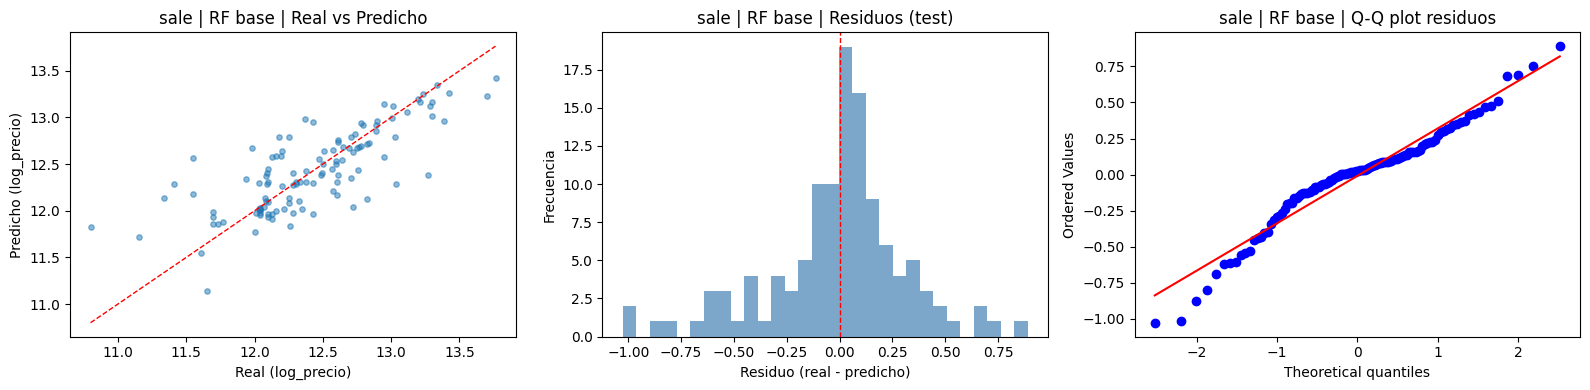

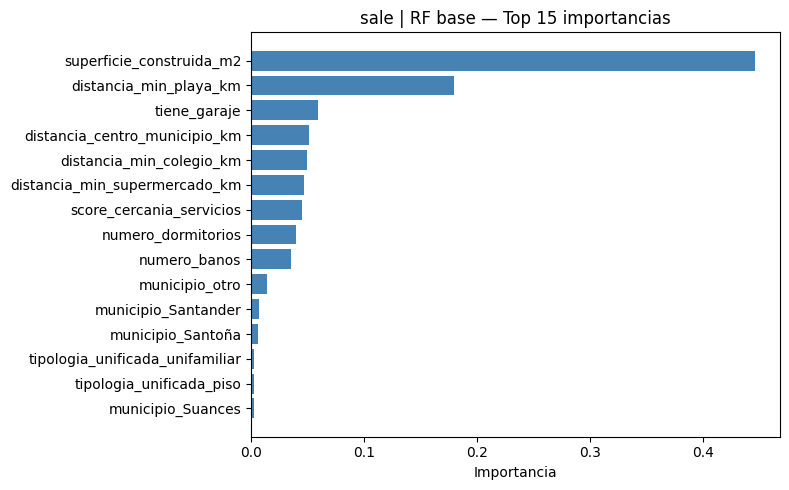


--- Random Forest | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}
  CV RMSE (mejor): 0.35348
split     MSE    RMSE     MAE      R2    MAPE
train 0.01527 0.12357 0.08767 0.95326 0.00715
   CV     NaN 0.35348     NaN     NaN     NaN
 test 0.09340 0.30561 0.21158 0.65697 0.01725
  Sobreajuste -> ratio RMSE test/train: 2.4732 | delta R2: 0.2963


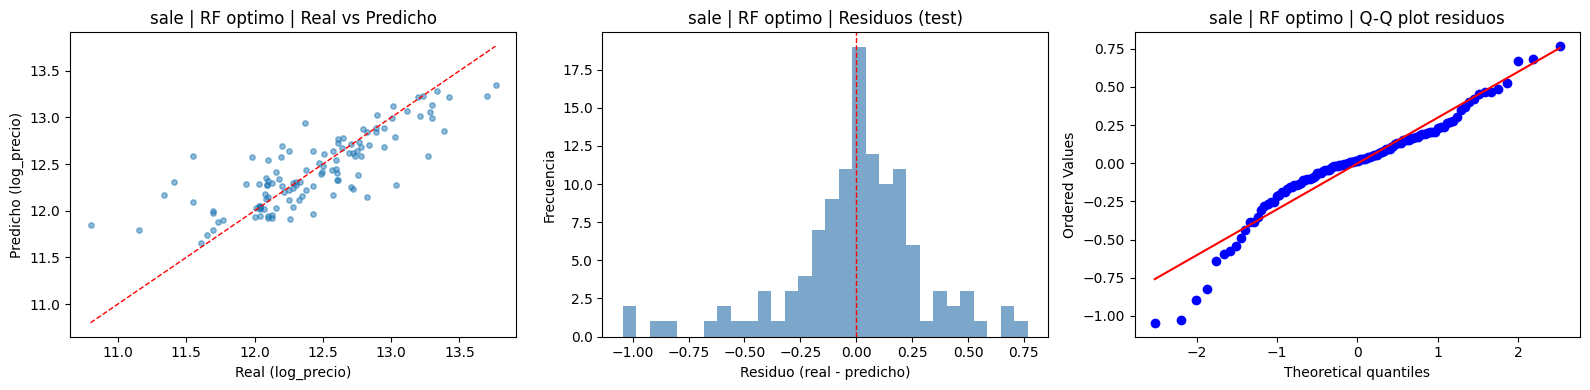

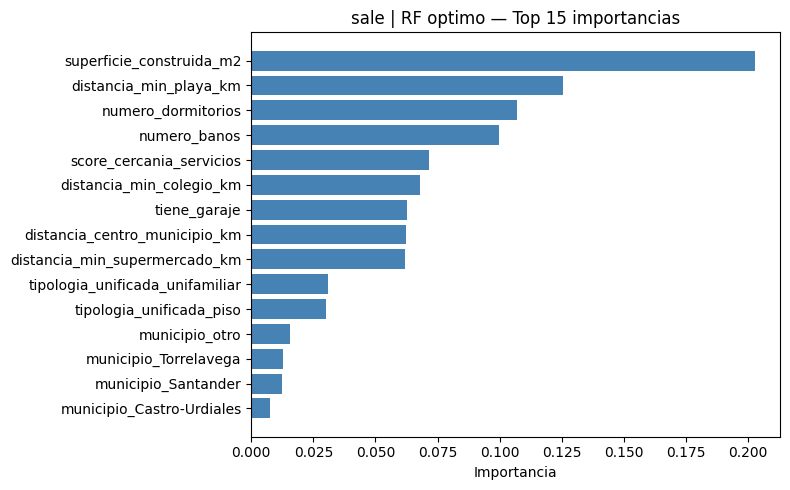


------------------------------------------------------------
EXTRA TREES
------------------------------------------------------------

--- Extra Trees | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00002 0.00456 0.00086 0.99994 0.00007
 test 0.08224 0.28677 0.20582 0.69796 0.01676
  Sobreajuste -> ratio RMSE test/train: 62.8882 | delta R2: 0.3020


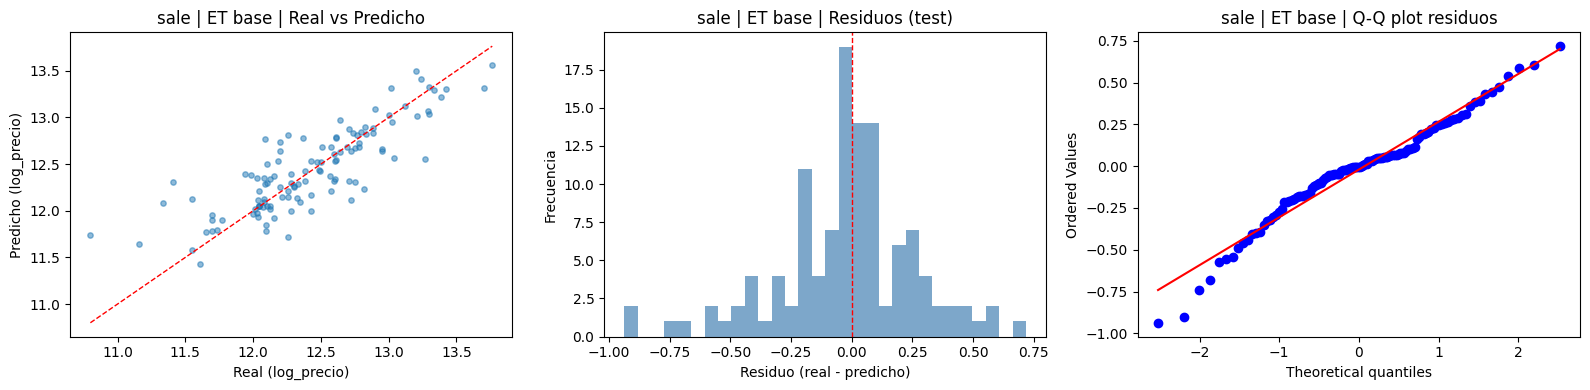

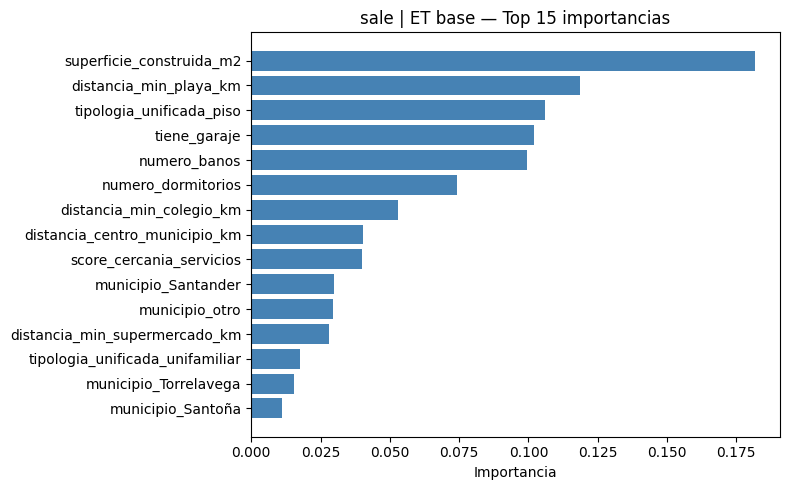


--- Extra Trees | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': 20, 'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 400}
  CV RMSE (mejor): 0.33306
split     MSE    RMSE     MAE      R2    MAPE
train 0.00006 0.00806 0.00319 0.99980 0.00026
   CV     NaN 0.33306     NaN     NaN     NaN
 test 0.07991 0.28268 0.20556 0.70651 0.01674
  Sobreajuste -> ratio RMSE test/train: 35.0720 | delta R2: 0.2933


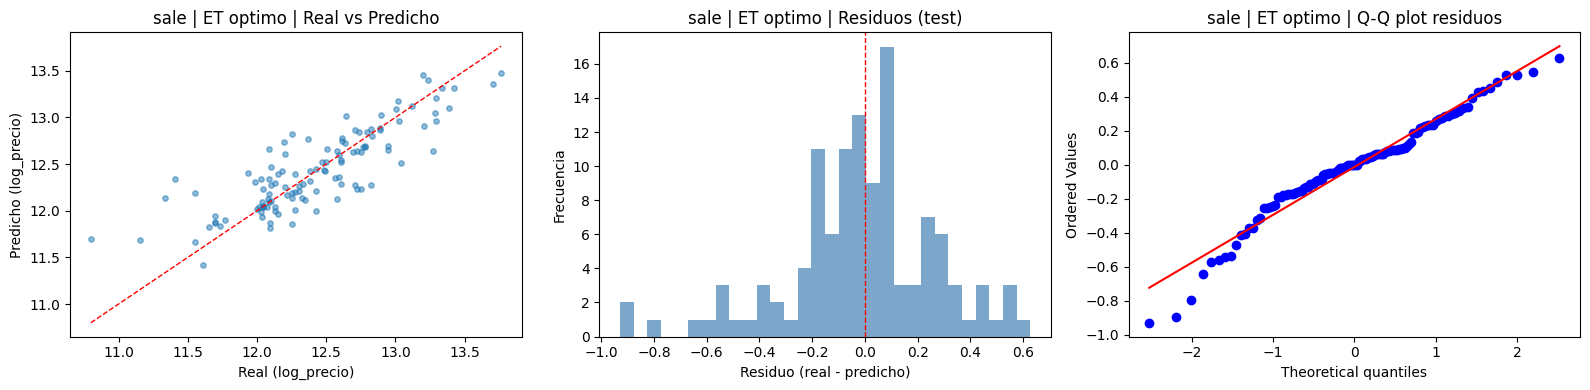

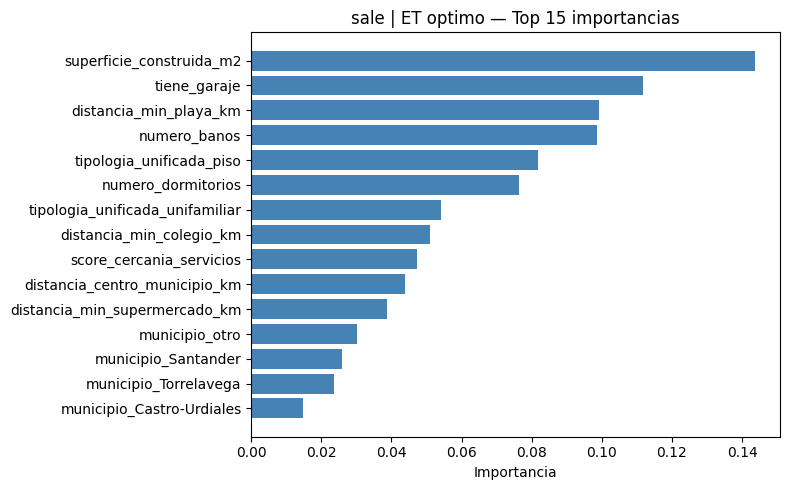


------------------------------------------------------------
RANDOM FOREST REGULARIZADO (ccp_alpha)
------------------------------------------------------------
  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.

--- RF Regularizado | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.06731 0.25944 0.18516 0.79396 0.01509
 test 0.10996 0.33160 0.23586 0.59614 0.01919
  Sobreajuste -> ratio RMSE test/train: 1.2781 | delta R2: 0.1978


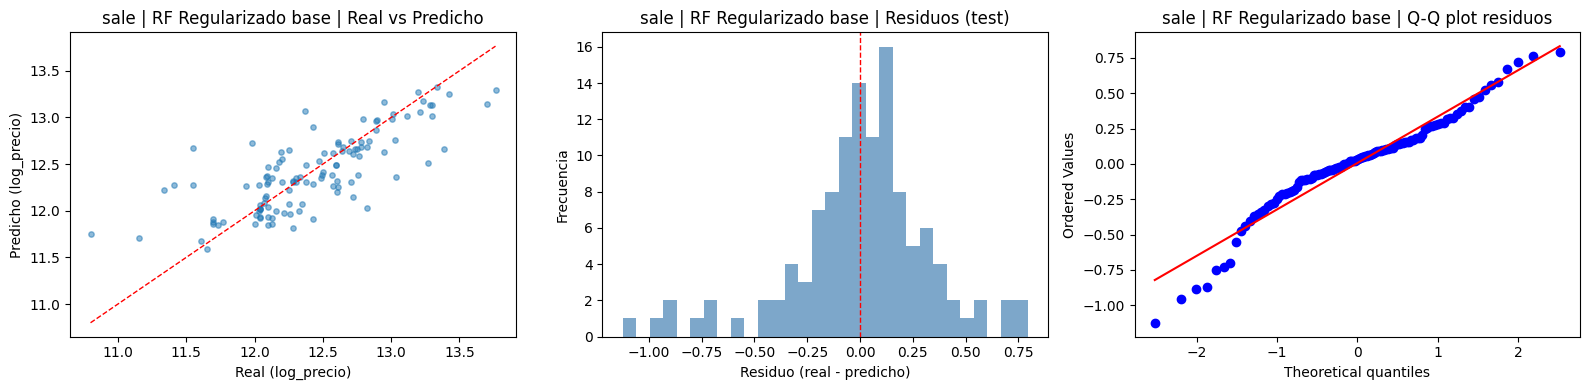

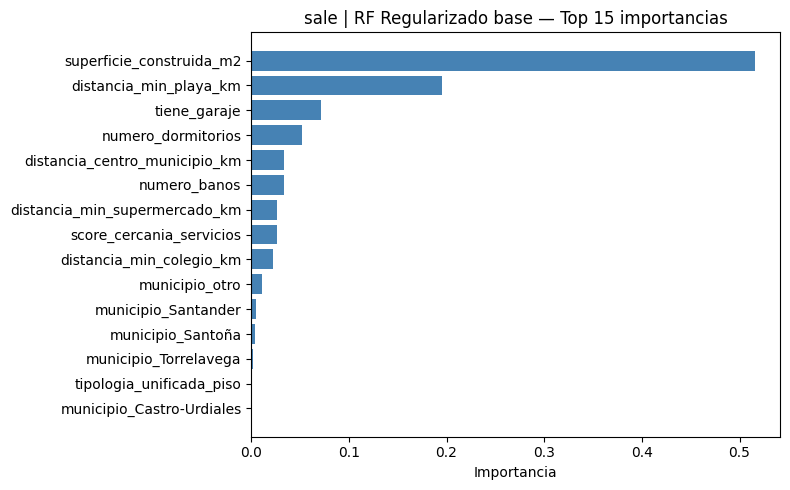


--- RF Regularizado | GridSearch (108 combinaciones, CV=5) ---
  Mejores params: {'ccp_alpha': 0.0001, 'max_depth': 15, 'max_features': 0.4, 'min_samples_leaf': 5, 'n_estimators': 200}
  CV RMSE (mejor): 0.36225
split     MSE    RMSE     MAE      R2    MAPE
train 0.06829 0.26132 0.18447 0.79097 0.01505
   CV     NaN 0.36225     NaN     NaN     NaN
 test 0.10791 0.32849 0.23149 0.60368 0.01883
  Sobreajuste -> ratio RMSE test/train: 1.2570 | delta R2: 0.1873


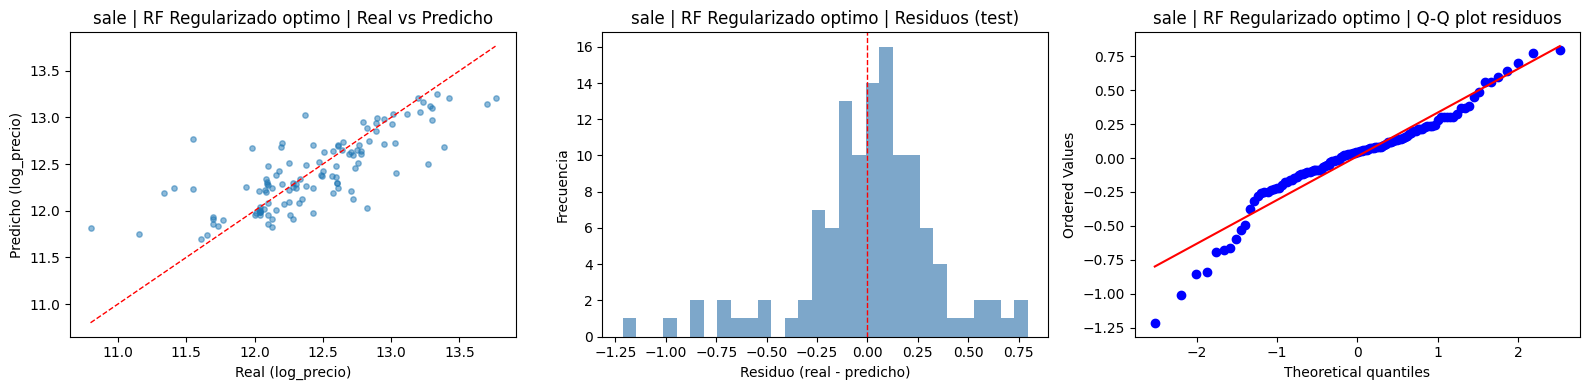

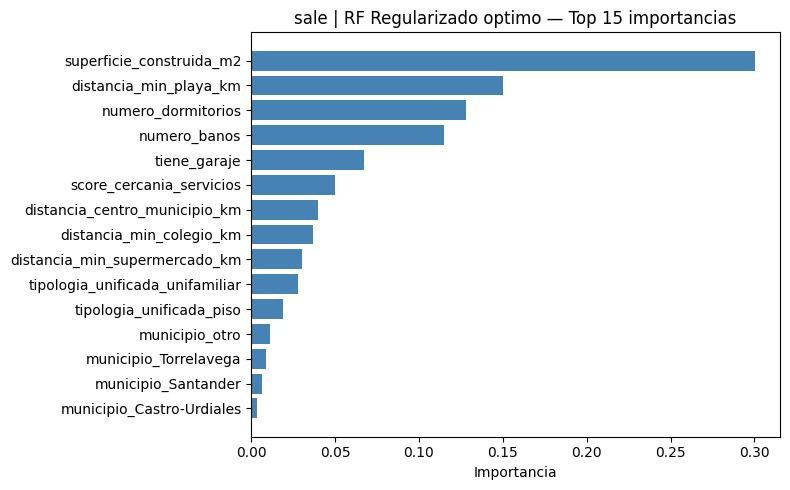


Quantile RF omitido: instala quantile-forest con: pip install quantile-forest

RESUMEN SALE — comparativa modelos
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale         RF   base     0.13174    0.33094   0.94688  0.59774      NaN
   sale         RF optimo     0.12357    0.30561   0.95326  0.65697  0.35348
   sale ExtraTrees   base     0.00456    0.28677   0.99994  0.69796      NaN
   sale ExtraTrees optimo     0.00806    0.28268   0.99980  0.70651  0.33306
   sale     RF_Reg   base     0.25944    0.33160   0.79396  0.59614      NaN
   sale     RF_Reg optimo     0.26132    0.32849   0.79097  0.60368  0.36225

DATASET: RENT
Filas cargadas: 477

Agrupando municipios con < 10 observaciones:
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (-> municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getx

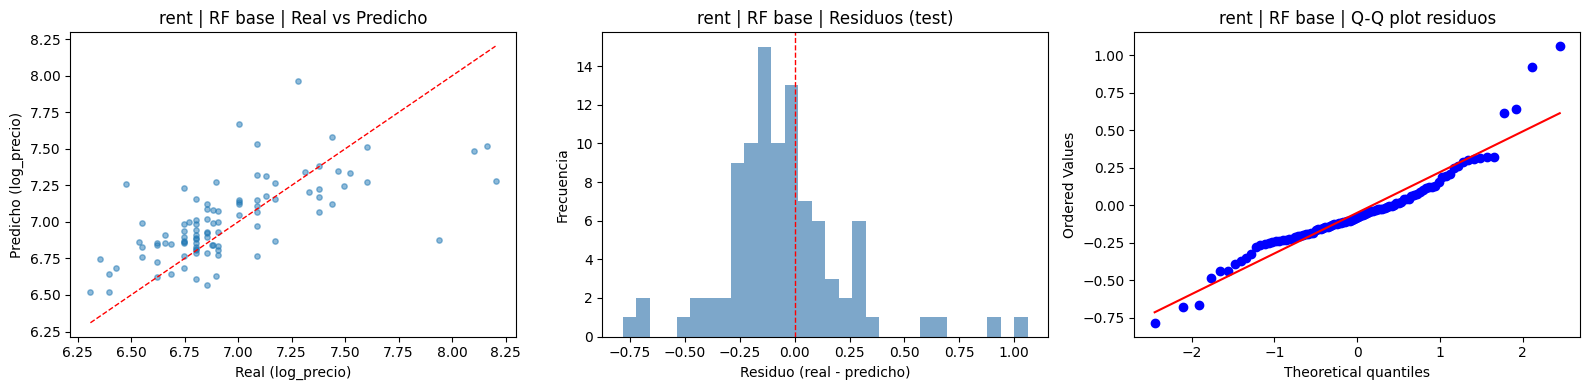

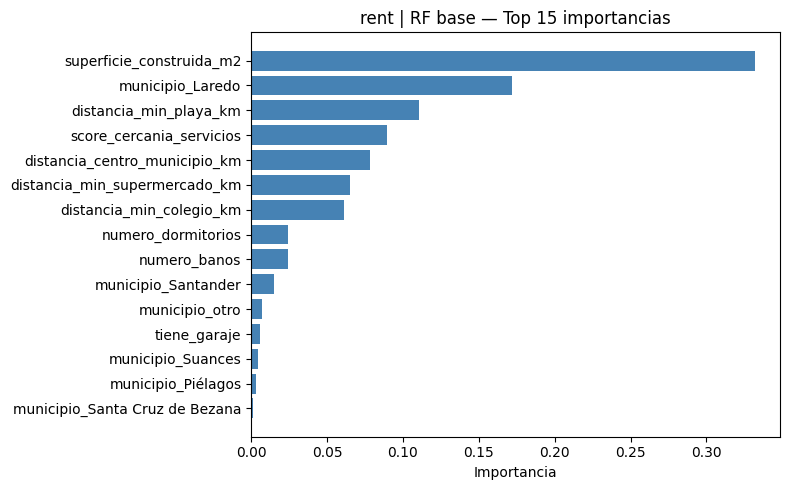


--- Random Forest | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': 10, 'max_features': 0.6, 'min_samples_leaf': 5, 'n_estimators': 400}
  CV RMSE (mejor): 0.29789
split     MSE    RMSE     MAE      R2    MAPE
train 0.05045 0.22462 0.15440 0.68189 0.02170
   CV     NaN 0.29789     NaN     NaN     NaN
 test 0.07501 0.27388 0.19304 0.44976 0.02729
  Sobreajuste -> ratio RMSE test/train: 1.2193 | delta R2: 0.2321


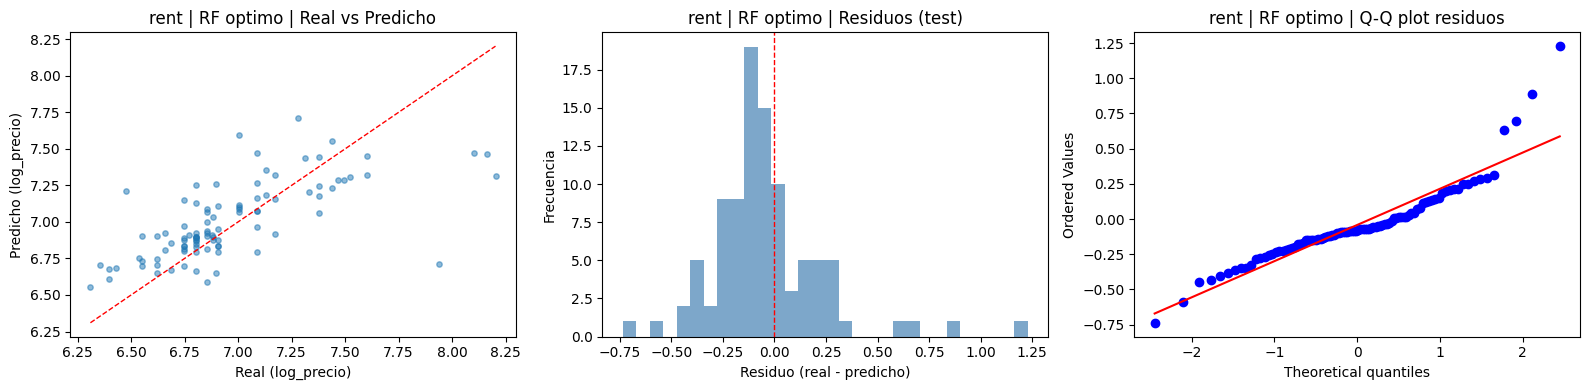

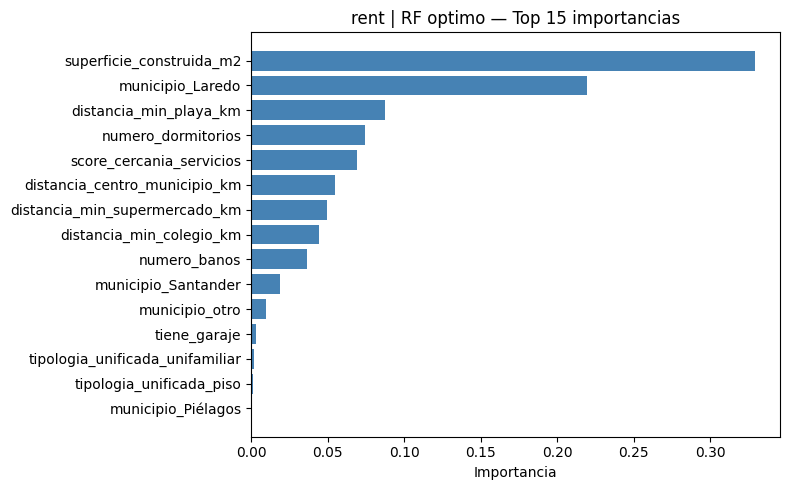


------------------------------------------------------------
EXTRA TREES
------------------------------------------------------------

--- Extra Trees | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.00074 0.02719 0.00257 0.99534 0.00034
 test 0.10736 0.32765 0.22325 0.21248 0.03166
  Sobreajuste -> ratio RMSE test/train: 12.0504 | delta R2: 0.7829


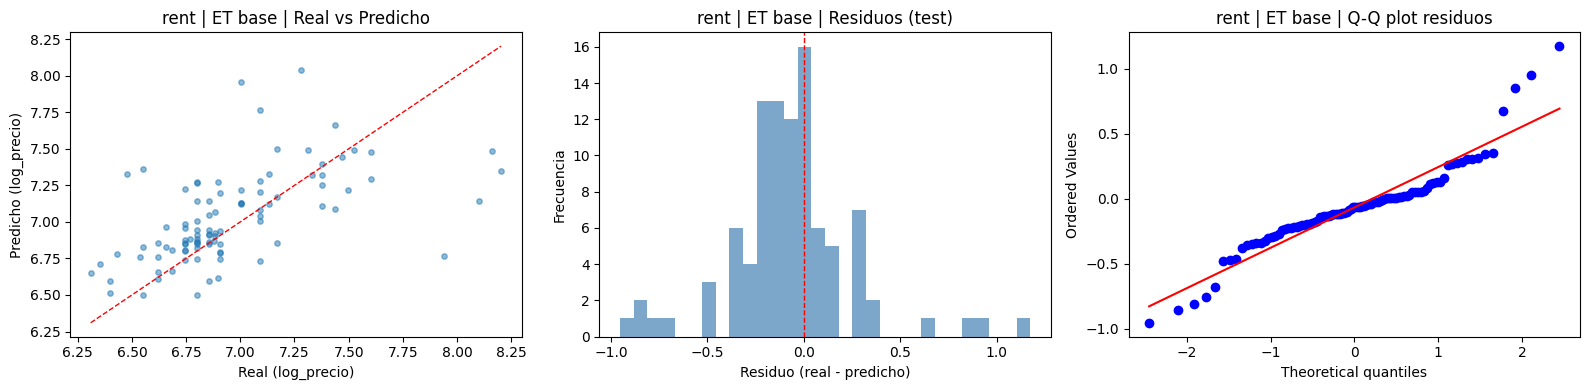

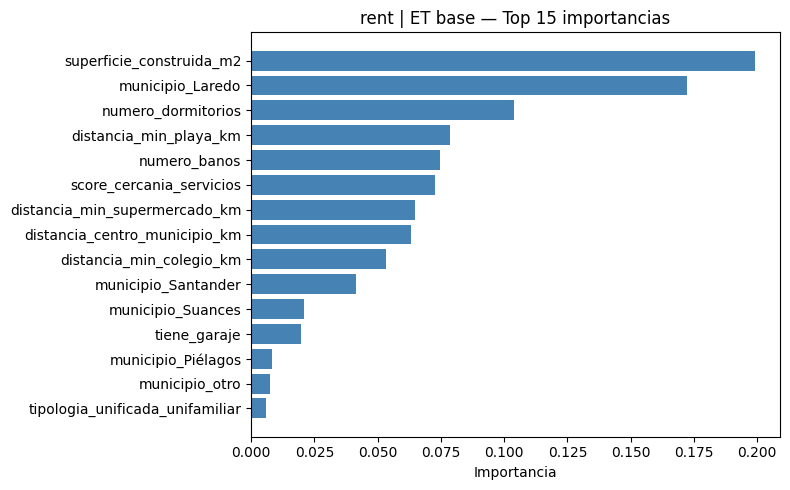


--- Extra Trees | GridSearch (54 combinaciones, CV=5) ---
  Mejores params: {'max_depth': 20, 'max_features': 0.6, 'min_samples_leaf': 5, 'n_estimators': 400}
  CV RMSE (mejor): 0.29248
split     MSE    RMSE     MAE      R2    MAPE
train 0.05726 0.23929 0.16463 0.63897 0.02318
   CV     NaN 0.29248     NaN     NaN     NaN
 test 0.08290 0.28792 0.20241 0.39191 0.02864
  Sobreajuste -> ratio RMSE test/train: 1.2032 | delta R2: 0.2471


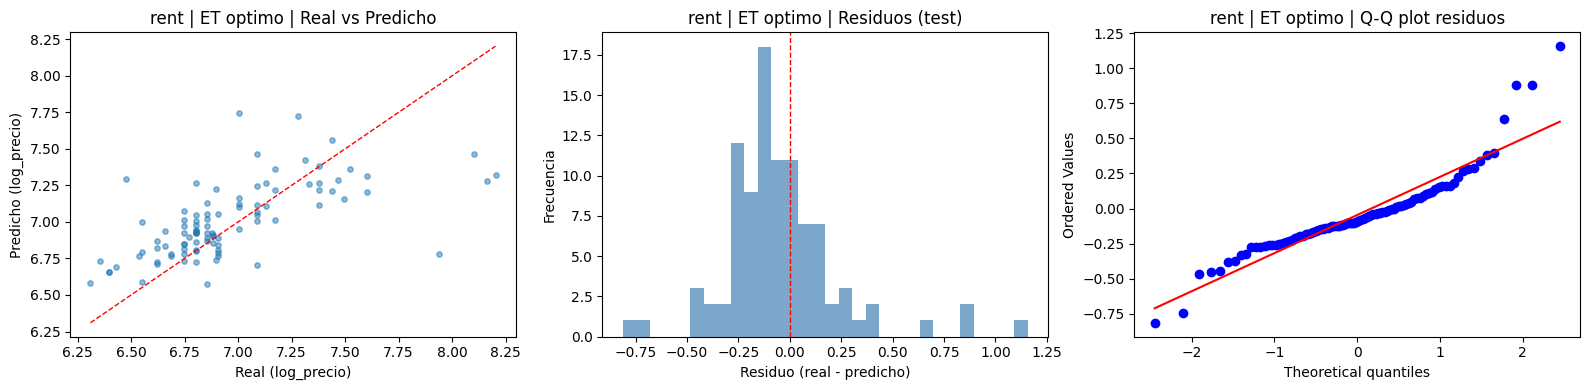

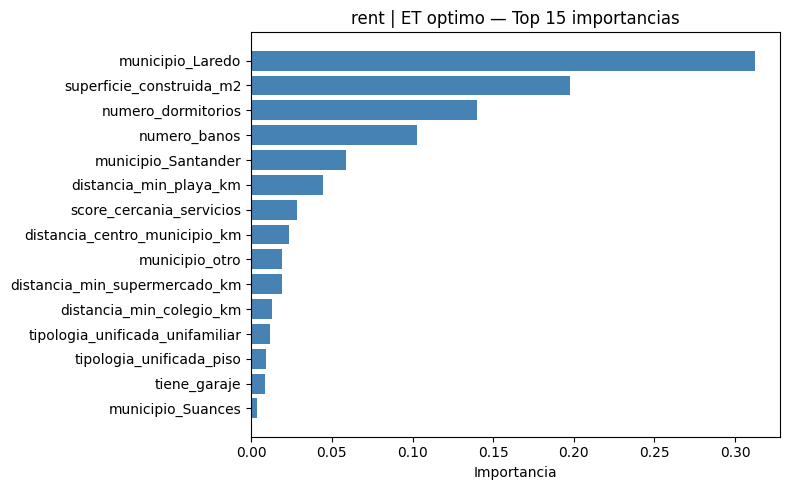


------------------------------------------------------------
RANDOM FOREST REGULARIZADO (ccp_alpha)
------------------------------------------------------------
  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.

--- RF Regularizado | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.05407 0.23254 0.16494 0.65905 0.02325
 test 0.07691 0.27733 0.19473 0.43582 0.02750
  Sobreajuste -> ratio RMSE test/train: 1.1926 | delta R2: 0.2232


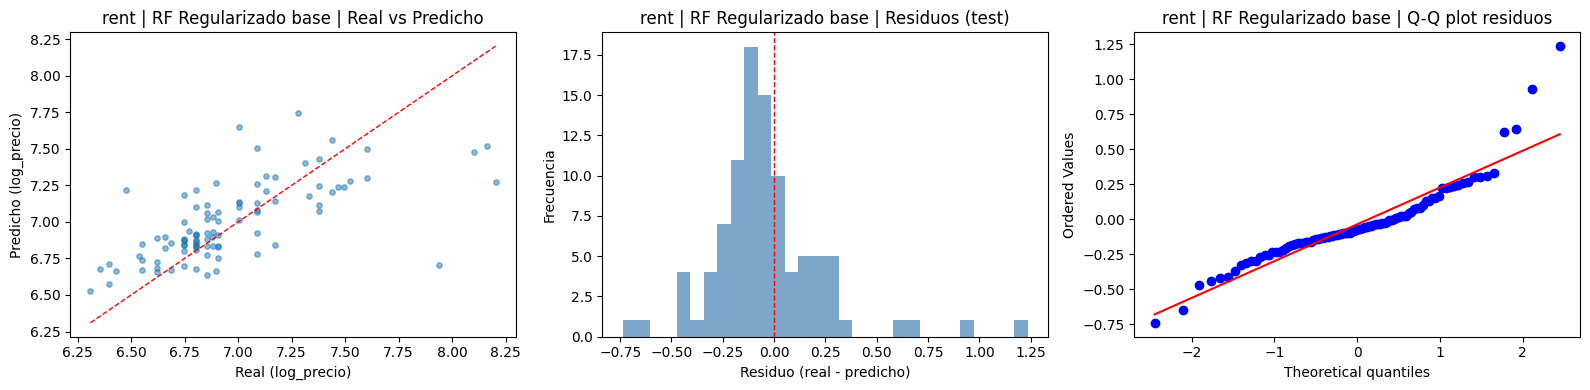

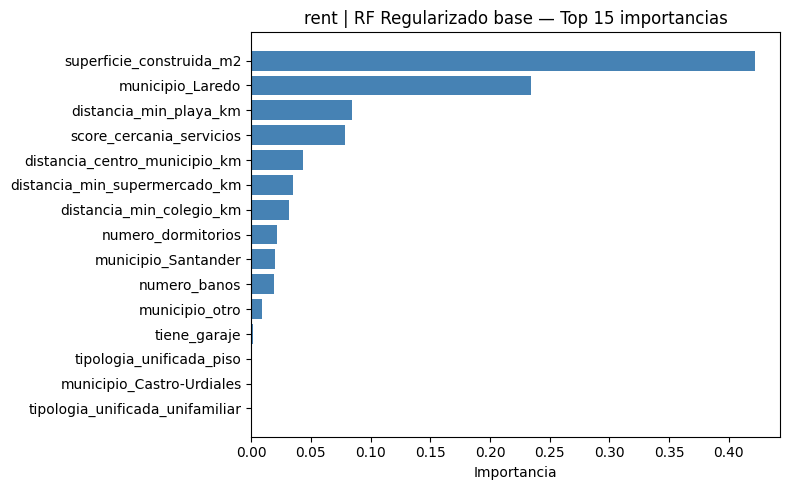


--- RF Regularizado | GridSearch (108 combinaciones, CV=5) ---
  Mejores params: {'ccp_alpha': 0.0001, 'max_depth': 10, 'max_features': 0.4, 'min_samples_leaf': 5, 'n_estimators': 400}
  CV RMSE (mejor): 0.30049
split     MSE    RMSE     MAE      R2    MAPE
train 0.05443 0.23329 0.16172 0.65684 0.02272
   CV     NaN 0.30049     NaN     NaN     NaN
 test 0.07520 0.27423 0.19247 0.44835 0.02722
  Sobreajuste -> ratio RMSE test/train: 1.1755 | delta R2: 0.2085


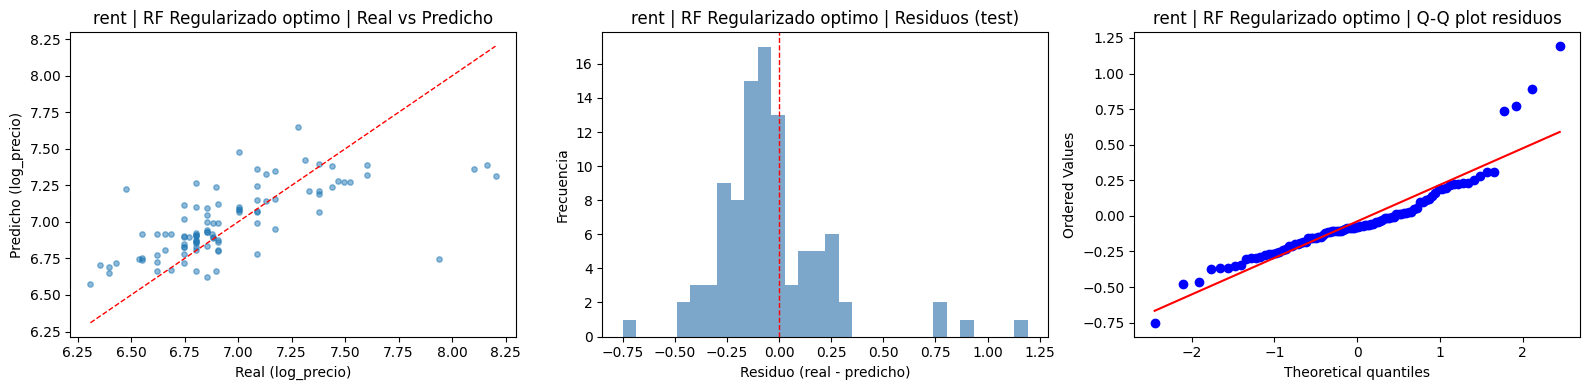

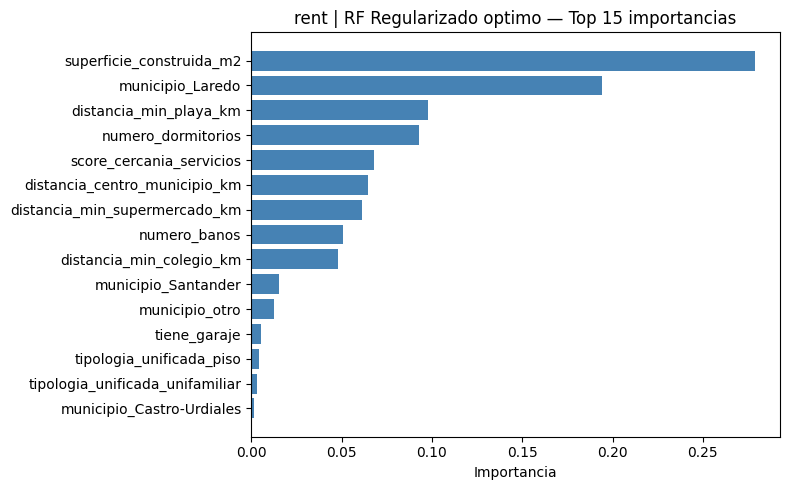


Quantile RF omitido: instala quantile-forest con: pip install quantile-forest

RESUMEN RENT — comparativa modelos
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent         RF   base     0.11785    0.28321   0.91243  0.41163      NaN
   rent         RF optimo     0.22462    0.27388   0.68189  0.44976  0.29789
   rent ExtraTrees   base     0.02719    0.32765   0.99534  0.21248      NaN
   rent ExtraTrees optimo     0.23929    0.28792   0.63897  0.39191  0.29248
   rent     RF_Reg   base     0.23254    0.27733   0.65905  0.43582      NaN
   rent     RF_Reg optimo     0.23329    0.27423   0.65684  0.44835  0.30049

RESUMEN GLOBAL
dataset     modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale         RF   base     0.13174    0.33094   0.94688  0.59774      NaN
   sale         RF optimo     0.12357    0.30561   0.95326  0.65697  0.35348
   sale ExtraTrees   base     0.00456    0.28677   0.99994  0.69796      NaN
   sale ExtraTrees opt

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,RF,base,0.13174,0.33094,0.94688,0.59774,NaN
1,sale,RF,optimo,0.12357,0.30561,0.95326,0.65697,0.353482
2,sale,ExtraTrees,base,0.00456,0.28677,0.99994,0.69796,NaN
3,sale,ExtraTrees,optimo,0.00806,0.28268,0.99980,0.70651,0.333064
4,sale,RF_Reg,base,0.25944,0.33160,0.79396,0.59614,NaN
5,sale,RF_Reg,optimo,0.26132,0.32849,0.79097,0.60368,0.362247
6,rent,RF,base,0.11785,0.28321,0.91243,0.41163,NaN
7,rent,RF,optimo,0.22462,0.27388,0.68189,0.44976,0.297890
8,rent,ExtraTrees,base,0.02719,0.32765,0.99534,0.21248,NaN
9,rent,ExtraTrees,optimo,0.23929,0.28792,0.63897,0.39191,0.292478


In [4]:
# ── Bucle principal ───────────────────────────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Colapsar municipios raros ─────────────────────────────────────────────
    print(f"\nAgrupando municipios con < {MIN_OBS_MUNICIPIO} observaciones:")
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)

    # ── Preparar features y split ─────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")
    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. Random Forest
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("RANDOM FOREST")
    print("-" * 60)

    rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    rf_base, rf_base_train, rf_base_test = run_base_model(
        rf_base, X_train, X_test, y_train, y_test, "Random Forest"
    )
    plot_diagnostics(y_test, rf_base.predict(X_test), f"{dataset_name} | RF base")
    plot_feature_importance(
        rf_base.feature_importances_, feature_names,
        f"{dataset_name} | RF base — Top 15 importancias"
    )

    rf_opt, rf_gs, rf_opt_train, rf_opt_test, rf_cv_rmse = run_grid_search(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_RF, X_train, X_test, y_train, y_test, "Random Forest"
    )
    plot_diagnostics(y_test, rf_opt.predict(X_test), f"{dataset_name} | RF optimo")
    plot_feature_importance(
        rf_opt.feature_importances_, feature_names,
        f"{dataset_name} | RF optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. Extra Trees
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("EXTRA TREES")
    print("-" * 60)

    et_base = ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    et_base, et_base_train, et_base_test = run_base_model(
        et_base, X_train, X_test, y_train, y_test, "Extra Trees"
    )
    plot_diagnostics(y_test, et_base.predict(X_test), f"{dataset_name} | ET base")
    plot_feature_importance(
        et_base.feature_importances_, feature_names,
        f"{dataset_name} | ET base — Top 15 importancias"
    )

    et_opt, et_gs, et_opt_train, et_opt_test, et_cv_rmse = run_grid_search(
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_ET, X_train, X_test, y_train, y_test, "Extra Trees"
    )
    plot_diagnostics(y_test, et_opt.predict(X_test), f"{dataset_name} | ET optimo")
    plot_feature_importance(
        et_opt.feature_importances_, feature_names,
        f"{dataset_name} | ET optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. RF Regularizado (ccp_alpha)
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "-" * 60)
    print("RANDOM FOREST REGULARIZADO (ccp_alpha)")
    print("-" * 60)
    print("  ccp_alpha: poda por complejidad de costo. Mayor valor = arboles mas simples.")

    rrf_base = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        ccp_alpha=0.001,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rrf_base, rrf_base_train, rrf_base_test = run_base_model(
        rrf_base, X_train, X_test, y_train, y_test, "RF Regularizado"
    )
    plot_diagnostics(y_test, rrf_base.predict(X_test), f"{dataset_name} | RF Regularizado base")
    plot_feature_importance(
        rrf_base.feature_importances_, feature_names,
        f"{dataset_name} | RF Regularizado base — Top 15 importancias"
    )

    rrf_opt, rrf_gs, rrf_opt_train, rrf_opt_test, rrf_cv_rmse = run_grid_search(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        PARAM_GRID_RRF, X_train, X_test, y_train, y_test, "RF Regularizado"
    )
    plot_diagnostics(y_test, rrf_opt.predict(X_test), f"{dataset_name} | RF Regularizado optimo")
    plot_feature_importance(
        rrf_opt.feature_importances_, feature_names,
        f"{dataset_name} | RF Regularizado optimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 4. Quantile Random Forest
    # ══════════════════════════════════════════════════════════════════════════
    if QRF_AVAILABLE:
        print("\n" + "-" * 60)
        print("QUANTILE RANDOM FOREST")
        print("-" * 60)
        print("  Prediccion puntual = mediana (q=0.5). Intervalo de confianza: q10-q90.")

        # Base
        qrf_base = RandomForestQuantileRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        qrf_base, qrf_base_train, qrf_base_test = run_qrf_base(
            qrf_base, X_train, X_test, y_train, y_test, "Quantile RF"
        )

        pred_med_base  = qrf_base.predict(X_test, quantiles=0.5)
        pred_low_base  = qrf_base.predict(X_test, quantiles=0.1)
        pred_high_base = qrf_base.predict(X_test, quantiles=0.9)

        plot_diagnostics(y_test, pred_med_base, f"{dataset_name} | QRF base")
        plot_prediction_intervals(
            y_test, pred_low_base, pred_med_base, pred_high_base,
            f"{dataset_name} | QRF base"
        )
        plot_feature_importance(
            qrf_base.feature_importances_, feature_names,
            f"{dataset_name} | QRF base — Top 15 importancias"
        )

        # Grid Search
        qrf_opt, qrf_gs, qrf_opt_train, qrf_opt_test, qrf_cv_rmse = run_qrf_grid_search(
            PARAM_GRID_QRF, X_train, X_test, y_train, y_test, "Quantile RF"
        )

        pred_med_opt  = qrf_opt.predict(X_test, quantiles=0.5)
        pred_low_opt  = qrf_opt.predict(X_test, quantiles=0.1)
        pred_high_opt = qrf_opt.predict(X_test, quantiles=0.9)

        plot_diagnostics(y_test, pred_med_opt, f"{dataset_name} | QRF optimo")
        plot_prediction_intervals(
            y_test, pred_low_opt, pred_med_opt, pred_high_opt,
            f"{dataset_name} | QRF optimo"
        )
        plot_feature_importance(
            qrf_opt.feature_importances_, feature_names,
            f"{dataset_name} | QRF optimo — Top 15 importancias"
        )
    else:
        print("\nQuantile RF omitido: instala quantile-forest con: pip install quantile-forest")
        qrf_base_train = qrf_base_test = qrf_opt_train = qrf_opt_test = None
        qrf_cv_rmse = None

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "RF",           "fase": "base",
         "train_RMSE": float(rf_base_train["RMSE"].iloc[0]),  "test_RMSE": float(rf_base_test["RMSE"].iloc[0]),
         "train_R2":   float(rf_base_train["R2"].iloc[0]),    "test_R2":   float(rf_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "RF",           "fase": "optimo",
         "train_RMSE": float(rf_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(rf_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(rf_opt_train["R2"].iloc[0]),     "test_R2":   float(rf_opt_test["R2"].iloc[0]),    "cv_RMSE": rf_cv_rmse},
        {"dataset": dataset_name, "modelo": "ExtraTrees",   "fase": "base",
         "train_RMSE": float(et_base_train["RMSE"].iloc[0]),  "test_RMSE": float(et_base_test["RMSE"].iloc[0]),
         "train_R2":   float(et_base_train["R2"].iloc[0]),    "test_R2":   float(et_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "ExtraTrees",   "fase": "optimo",
         "train_RMSE": float(et_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(et_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(et_opt_train["R2"].iloc[0]),     "test_R2":   float(et_opt_test["R2"].iloc[0]),    "cv_RMSE": et_cv_rmse},
        {"dataset": dataset_name, "modelo": "RF_Reg",       "fase": "base",
         "train_RMSE": float(rrf_base_train["RMSE"].iloc[0]), "test_RMSE": float(rrf_base_test["RMSE"].iloc[0]),
         "train_R2":   float(rrf_base_train["R2"].iloc[0]),   "test_R2":   float(rrf_base_test["R2"].iloc[0]),  "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "RF_Reg",       "fase": "optimo",
         "train_RMSE": float(rrf_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(rrf_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(rrf_opt_train["R2"].iloc[0]),    "test_R2":   float(rrf_opt_test["R2"].iloc[0]),   "cv_RMSE": rrf_cv_rmse},
    ]

    if QRF_AVAILABLE and qrf_opt_train is not None:
        rows += [
            {"dataset": dataset_name, "modelo": "QRF",        "fase": "base",
             "train_RMSE": float(qrf_base_train["RMSE"].iloc[0]), "test_RMSE": float(qrf_base_test["RMSE"].iloc[0]),
             "train_R2":   float(qrf_base_train["R2"].iloc[0]),   "test_R2":   float(qrf_base_test["R2"].iloc[0]),  "cv_RMSE": None},
            {"dataset": dataset_name, "modelo": "QRF",        "fase": "optimo",
             "train_RMSE": float(qrf_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(qrf_opt_test["RMSE"].iloc[0]),
             "train_R2":   float(qrf_opt_train["R2"].iloc[0]),    "test_R2":   float(qrf_opt_test["R2"].iloc[0]),   "cv_RMSE": qrf_cv_rmse},
        ]

    all_summary_rows.extend(rows)
    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary

---

## Análisis: Extra Trees con R²≈0.99 en train — overfitting aparente y buena generalización

### Por qué Extra Trees memoriza el train casi perfectamente

Extra Trees (`ExtraTreesRegressor`) se diferencia de Random Forest en que **los puntos de corte de cada split se eligen completamente al azar** (en lugar de buscar el mejor entre candidatos). Esto tiene una consecuencia directa sobre el comportamiento en train:

- Con **`min_samples_leaf=1`** (por defecto), cada árbol crece sin restricción de profundidad hasta que cada hoja contiene exactamente 1 muestra.
- Como los splits son aleatorios, el árbol necesita crecer **más profundo** que un árbol de RF para separar los puntos, lo que produce una memorización perfecta del conjunto de entrenamiento (R²≈1.0 en train).
- Esto es overfitting estructural: no indica que el modelo sea malo, sino que los árboles individuales son muy profundos.

### Por qué aun así generaliza bien

El secreto está en el **ensemble**:

1. **Decorrelación extrema**: al ser los splits totalmente aleatorios, los árboles del ensemble están mucho menos correlacionados entre sí que en RF. Al promediar predictores decorrelacionados, la varianza del ensemble cae mucho más rápido.
2. **El sesgo de cada árbol es alto, pero el ensemble lo compensa**: ningún árbol individual generaliza bien, pero el promedio de cientos de árboles con sesgos distintos converge a una estimación estable.
3. **Analogía**: es como promediar muchas estimaciones ruidosas pero no sesgadas en la misma dirección — el ruido se cancela, la señal persiste.

### Experimentos

Los siguientes análisis estudian empíricamente este fenómeno:

1. **Barrido de `min_samples_leaf`**: cómo cambian train R² y test R² al aumentar el tamaño mínimo de hoja.
2. **Efecto del número de árboles**: cómo el promedio de más árboles reduce la varianza del ensemble.
3. **ET vs RF**: comparación directa en el mismo grid de hiperparámetros.
4. **Profundidad de los árboles**: distribución de profundidad de los árboles individuales con distintos `min_samples_leaf`.


### Experimento 1 — Barrido de `min_samples_leaf`: train R² vs test R²

¿Cuánto cae el R² de test cuando subimos `min_samples_leaf`? ¿Y el de train?

  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (-> municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municip

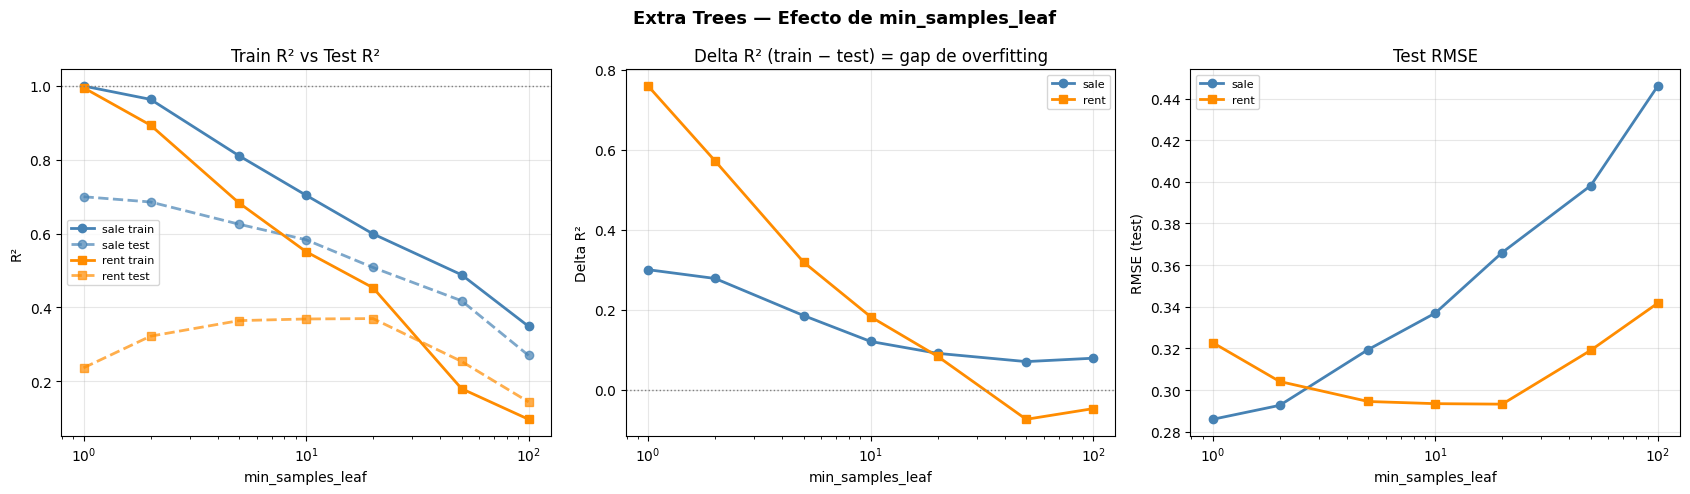

In [5]:
leaf_values = [1, 2, 5, 10, 20, 50, 100]
n_estimators_fixed = 200

leaf_sweep_rows = []

for dataset_name, dataset_path in DATASETS.items():
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    for leaf in leaf_values:
        et = ExtraTreesRegressor(
            n_estimators=n_estimators_fixed,
            min_samples_leaf=leaf,
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        et.fit(X_train, y_train)
        r2_train = r2_score(y_train, et.predict(X_train))
        r2_test  = r2_score(y_test,  et.predict(X_test))
        rmse_test = np.sqrt(mean_squared_error(y_test, et.predict(X_test)))
        leaf_sweep_rows.append({
            "dataset":        dataset_name,
            "min_samples_leaf": leaf,
            "train_R2":       round(r2_train, 5),
            "test_R2":        round(r2_test,  5),
            "delta_R2":       round(r2_train - r2_test, 5),
            "test_RMSE":      round(rmse_test, 5),
        })

leaf_df = pd.DataFrame(leaf_sweep_rows)
print("Barrido min_samples_leaf — Extra Trees (n_estimators=200, max_depth=None)")
print(leaf_df.to_string(index=False))

# ── Gráfico ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Extra Trees — Efecto de min_samples_leaf", fontsize=13, fontweight="bold")

for ds, color, marker in [("sale", "steelblue", "o"), ("rent", "darkorange", "s")]:
    sub = leaf_df[leaf_df["dataset"] == ds]

    axes[0].plot(sub["min_samples_leaf"], sub["train_R2"], color=color, marker=marker,
                 label=f"{ds} train", linewidth=2)
    axes[0].plot(sub["min_samples_leaf"], sub["test_R2"], color=color, marker=marker,
                 linestyle="--", label=f"{ds} test", linewidth=2, alpha=0.7)

    axes[1].plot(sub["min_samples_leaf"], sub["delta_R2"], color=color, marker=marker,
                 label=ds, linewidth=2)

    axes[2].plot(sub["min_samples_leaf"], sub["test_RMSE"], color=color, marker=marker,
                 label=ds, linewidth=2)

axes[0].set_title("Train R² vs Test R²")
axes[0].set_xlabel("min_samples_leaf")
axes[0].set_ylabel("R²")
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].legend(fontsize=8)

axes[1].set_title("Delta R² (train − test) = gap de overfitting")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("Delta R²")
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[1].legend(fontsize=8)

axes[2].set_title("Test RMSE")
axes[2].set_xlabel("min_samples_leaf")
axes[2].set_ylabel("RMSE (test)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Experimento 2 — Profundidad de los árboles individuales

Con `min_samples_leaf=1` los árboles crecen prácticamente sin límite. Aquí vemos la distribución de profundidad máxima de los árboles en el ensemble según el valor de `min_samples_leaf`.

  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']


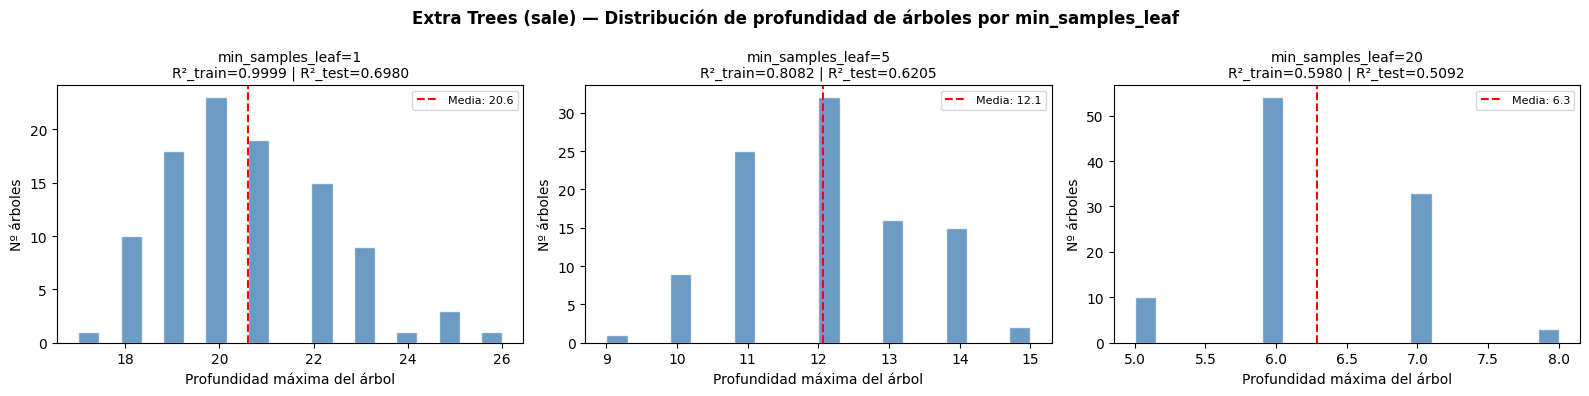


Resumen profundidad vs R² (sale, n_estimators=100):
 min_samples_leaf  depth_media  depth_max  depth_min  train_R2  test_R2
                1         20.6         26         17   0.99994  0.69796
                5         12.1         15          9   0.80822  0.62051
               20          6.3          8          5   0.59801  0.50920

Nota: con min_samples_leaf=1, los árboles tienen ~21 niveles de profundidad media.
Cada árbol esencialmente memoriza el train, pero el promedio del ensemble cancela el ruido.


In [6]:
# Usamos el último dataset del bucle principal (rent) — recargar sale para análisis completo
df_sale = pd.read_csv(DATASETS["sale"])
df_sale = df_sale[df_sale[TARGET_COL].notna()].copy()
df_sale, fm_sale = collapse_rare_municipios(df_sale, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)
X_sale = prepare_X(df_sale, BASE_FEATURES + fm_sale)
y_sale = df_sale[TARGET_COL].values
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_sale, y_sale, test_size=TEST_SIZE, random_state=RANDOM_STATE)

leaf_values_depth = [1, 5, 20]
n_trees_depth     = 100  # menos árboles para que sea rápido

fig, axes = plt.subplots(1, len(leaf_values_depth), figsize=(16, 4), sharey=False)
fig.suptitle("Extra Trees (sale) — Distribución de profundidad de árboles por min_samples_leaf",
             fontsize=12, fontweight="bold")

depth_stats = []
for ax, leaf in zip(axes, leaf_values_depth):
    et = ExtraTreesRegressor(
        n_estimators=n_trees_depth,
        min_samples_leaf=leaf,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    et.fit(Xtr_s, ytr_s)
    depths = [tree.get_depth() for tree in et.estimators_]
    r2_tr  = r2_score(ytr_s, et.predict(Xtr_s))
    r2_te  = r2_score(yte_s, et.predict(Xte_s))

    ax.hist(depths, bins=20, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(np.mean(depths), color="red", linestyle="--", linewidth=1.5,
               label=f"Media: {np.mean(depths):.1f}")
    ax.set_title(f"min_samples_leaf={leaf}\nR²_train={r2_tr:.4f} | R²_test={r2_te:.4f}",
                 fontsize=10)
    ax.set_xlabel("Profundidad máxima del árbol")
    ax.set_ylabel("Nº árboles")
    ax.legend(fontsize=8)

    depth_stats.append({
        "min_samples_leaf": leaf,
        "depth_media":      round(np.mean(depths), 1),
        "depth_max":        max(depths),
        "depth_min":        min(depths),
        "train_R2":         round(r2_tr, 5),
        "test_R2":          round(r2_te, 5),
    })

plt.tight_layout()
plt.show()

print("\nResumen profundidad vs R² (sale, n_estimators=100):")
print(pd.DataFrame(depth_stats).to_string(index=False))
print(f"\nNota: con min_samples_leaf=1, los árboles tienen ~{depth_stats[0]['depth_media']:.0f} niveles de profundidad media.")
print("Cada árbol esencialmente memoriza el train, pero el promedio del ensemble cancela el ruido.")


### Experimento 3 — El promedio como regularizador: 1 árbol vs N árboles

Si el overfitting viene de los árboles individuales, aumentar el número de árboles debería **reducir el gap train-test** manteniendo o mejorando el test R².

  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (-> municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municip

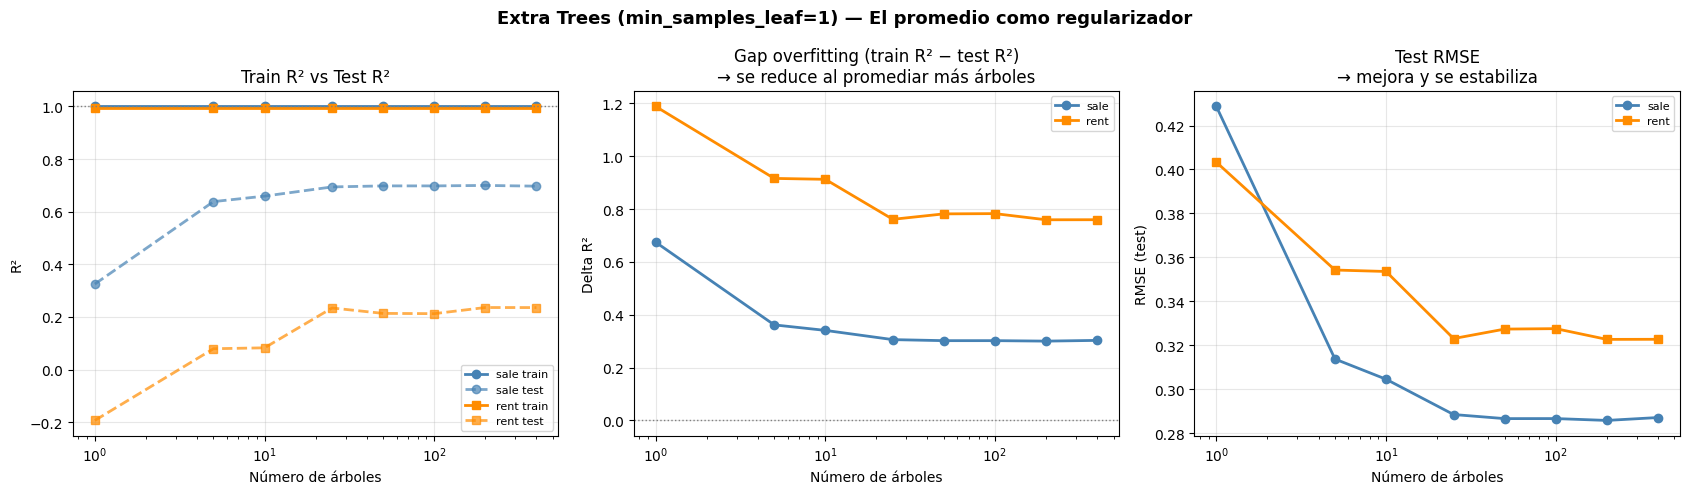

In [7]:
n_trees_sweep = [1, 5, 10, 25, 50, 100, 200, 400]

ensemble_rows = []
for dataset_name, dataset_path in DATASETS.items():
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    df, fm = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)
    X = prepare_X(df, BASE_FEATURES + fm)
    y = df[TARGET_COL].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    for n_trees in n_trees_sweep:
        # ET con min_samples_leaf=1 (configuración que produce R²≈0.99 en train)
        et = ExtraTreesRegressor(
            n_estimators=n_trees,
            min_samples_leaf=1,
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        et.fit(Xtr, ytr)
        r2_tr   = r2_score(ytr, et.predict(Xtr))
        r2_te   = r2_score(yte, et.predict(Xte))
        rmse_te = np.sqrt(mean_squared_error(yte, et.predict(Xte)))
        ensemble_rows.append({
            "dataset":    dataset_name,
            "n_trees":    n_trees,
            "train_R2":   round(r2_tr,   5),
            "test_R2":    round(r2_te,   5),
            "delta_R2":   round(r2_tr - r2_te, 5),
            "test_RMSE":  round(rmse_te, 5),
        })

ensemble_df = pd.DataFrame(ensemble_rows)
print("Efecto del número de árboles — ET (min_samples_leaf=1)")
print(ensemble_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Extra Trees (min_samples_leaf=1) — El promedio como regularizador",
             fontsize=13, fontweight="bold")

for ds, color, marker in [("sale", "steelblue", "o"), ("rent", "darkorange", "s")]:
    sub = ensemble_df[ensemble_df["dataset"] == ds]

    axes[0].plot(sub["n_trees"], sub["train_R2"], color=color, marker=marker,
                 label=f"{ds} train", linewidth=2)
    axes[0].plot(sub["n_trees"], sub["test_R2"], color=color, marker=marker,
                 linestyle="--", label=f"{ds} test", linewidth=2, alpha=0.7)

    axes[1].plot(sub["n_trees"], sub["delta_R2"], color=color, marker=marker,
                 label=ds, linewidth=2)

    axes[2].plot(sub["n_trees"], sub["test_RMSE"], color=color, marker=marker,
                 label=ds, linewidth=2)

axes[0].set_title("Train R² vs Test R²")
axes[0].set_xlabel("Número de árboles")
axes[0].set_ylabel("R²")
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].legend(fontsize=8)

axes[1].set_title("Gap overfitting (train R² − test R²)\n→ se reduce al promediar más árboles")
axes[1].set_xlabel("Número de árboles")
axes[1].set_ylabel("Delta R²")
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[1].legend(fontsize=8)

axes[2].set_title("Test RMSE\n→ mejora y se estabiliza")
axes[2].set_xlabel("Número de árboles")
axes[2].set_ylabel("RMSE (test)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Experimento 4 — ET vs RF: mismo grid, comparación directa

Random Forest optimiza el split en cada nodo → árboles menos profundos → menor R² en train. Extra Trees aleatoriza el split → árboles más profundos → mayor R² en train. ¿Cuál generaliza mejor en test?

  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (-> municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (-> municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municip

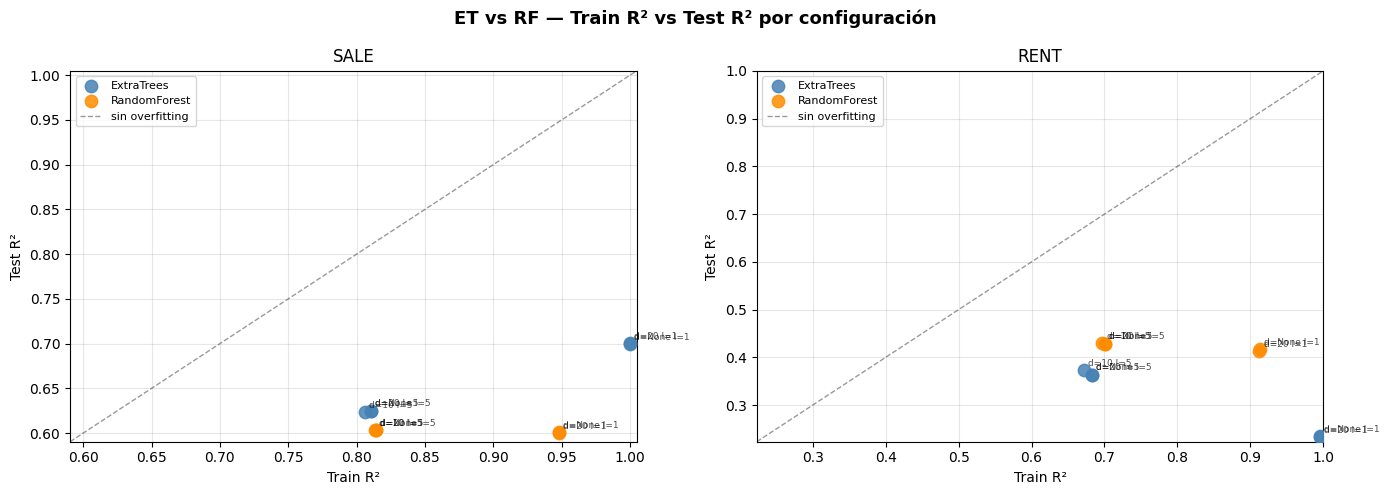


Ventaja ET sobre RF en test R² (positivo = ET gana):
dataset     config  ExtraTrees  RandomForest  ET_ventaja
   rent   d=10 l=5     0.37305       0.42964    -0.05659
   rent   d=20 l=1     0.23312       0.41271    -0.17959
   rent   d=20 l=5     0.36385       0.42888    -0.06503
   rent d=None l=1     0.23579       0.41640    -0.18061
   rent d=None l=5     0.36385       0.42888    -0.06503
   sale   d=10 l=5     0.62342       0.60371     0.01971
   sale   d=20 l=1     0.70014       0.60031     0.09983
   sale   d=20 l=5     0.62520       0.60349     0.02171
   sale d=None l=1     0.69972       0.60105     0.09867
   sale d=None l=5     0.62520       0.60349     0.02171


In [8]:
shared_configs = [
    {"n_estimators": 200, "max_depth": None,  "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None,  "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 20,    "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 20,    "min_samples_leaf": 5},
    {"n_estimators": 200, "max_depth": 10,    "min_samples_leaf": 5},
]

et_vs_rf_rows = []

for dataset_name, dataset_path in DATASETS.items():
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    df, fm = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)
    X = prepare_X(df, BASE_FEATURES + fm)
    y = df[TARGET_COL].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    for cfg in shared_configs:
        label = f"d={cfg['max_depth']} l={cfg['min_samples_leaf']}"
        for ModelClass, model_name in [
            (ExtraTreesRegressor,   "ExtraTrees"),
            (RandomForestRegressor, "RandomForest"),
        ]:
            m = ModelClass(random_state=RANDOM_STATE, n_jobs=-1, **cfg)
            m.fit(Xtr, ytr)
            et_vs_rf_rows.append({
                "dataset":          dataset_name,
                "modelo":           model_name,
                "config":           label,
                "max_depth":        str(cfg["max_depth"]),
                "min_samples_leaf": cfg["min_samples_leaf"],
                "train_R2":         round(r2_score(ytr, m.predict(Xtr)), 5),
                "test_R2":          round(r2_score(yte, m.predict(Xte)), 5),
                "test_RMSE":        round(np.sqrt(mean_squared_error(yte, m.predict(Xte))), 5),
            })

et_vs_rf_df = pd.DataFrame(et_vs_rf_rows)
et_vs_rf_df["delta_R2"] = (et_vs_rf_df["train_R2"] - et_vs_rf_df["test_R2"]).round(5)

print("ET vs RF — mismo grid de hiperparámetros")
print(et_vs_rf_df.to_string(index=False))

# ── Gráfico: scatter train R² vs test R² coloreado por modelo ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ET vs RF — Train R² vs Test R² por configuración", fontsize=13, fontweight="bold")

colors_model = {"ExtraTrees": "steelblue", "RandomForest": "darkorange"}

for ax, ds in zip(axes, ["sale", "rent"]):
    sub = et_vs_rf_df[et_vs_rf_df["dataset"] == ds]
    for model_name, color in colors_model.items():
        ms = sub[sub["modelo"] == model_name]
        ax.scatter(ms["train_R2"], ms["test_R2"], color=color, label=model_name,
                   s=80, alpha=0.85, zorder=3)
        # Anotar configuración
        for _, row in ms.iterrows():
            ax.annotate(
                row["config"],
                (row["train_R2"], row["test_R2"]),
                fontsize=6.5, alpha=0.7,
                xytext=(3, 3), textcoords="offset points",
            )
    # Línea diagonal (sin overfitting)
    lims = [
        min(sub["train_R2"].min(), sub["test_R2"].min()) - 0.01,
        max(sub["train_R2"].max(), sub["test_R2"].max()) + 0.005,
    ]
    ax.plot(lims, lims, "k--", linewidth=1, alpha=0.4, label="sin overfitting")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Train R²")
    ax.set_ylabel("Test R²")
    ax.set_title(f"{ds.upper()}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Resumen: diferencia ET - RF en test R² por configuración ──────────────────
print("\nVentaja ET sobre RF en test R² (positivo = ET gana):")
pivot = et_vs_rf_df.pivot_table(
    index=["dataset", "config"], columns="modelo", values="test_R2"
).reset_index()
pivot["ET_ventaja"] = (pivot["ExtraTrees"] - pivot["RandomForest"]).round(5)
print(pivot.to_string(index=False))


### Conclusiones

| Observación | Explicación |
|------------|-------------|
| **R²_train ≈ 0.99–1.0** en ET | Con `min_samples_leaf=1` y `max_depth=None`, los árboles crecen hasta tener 1 muestra por hoja. La memorización es total. |
| **R²_test sigue siendo bueno** | El promedio de cientos de árboles decorrelacionados cancela el ruido individual. La varianza del ensemble cae mucho más rápido que en RF porque los splits totalmente aleatorios producen árboles más diferentes entre sí. |
| **Al aumentar `min_samples_leaf`** | El R²_train cae (los árboles ya no memorizan), el gap de overfitting se cierra, pero el test R² cambia poco → el modelo base ya era robusto. |
| **Al aumentar `n_estimators`** | El gap train-test se reduce progresivamente → confirma que el overfitting es puro ruido de cada árbol, no sesgo del ensemble. |
| **ET vs RF** | En test suelen ser comparables o ET ligeramente mejor. En train, ET siempre tiene R² más alto. El scatter train R² vs test R² muestra que RF queda más cerca de la diagonal (menos gap), pero ET alcanza niveles similares de test R² partiendo de un train R² mucho más alto. |

**¿Es problemático el R²=0.99 en train?** No necesariamente. Es un artefacto de la forma en que ET construye sus árboles, no un indicador de que el modelo no sirva. La métrica relevante es siempre el test (y mejor aún, el CV RMSE del GridSearch).
